In [1]:
from pathlib import Path
from datetime import datetime
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    accuracy_score,
    recall_score,
    f1_score,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

from config.paths import MODEL_RUNS_DIR, FIGURES_DIR, RESULTS_DIR
from config.feature_groups import TARGET_COLUMN, RADON_HIGH_CONCENTRATION, RANDOM_STATE
from config.cv_params import (
    OUTER_FOLD_COLUMN,
    INNER_CV_GROUP_COLUMN,
    INNER_CV_STRATIFY_COLUMN,
    TEST_FLAG_COLUMN,
    N_INNER_SPLITS,
)
from src.data.data_loading import load_full_training_pool, load_test_data
from src.data.feature_handling import get_feature_columns
from src.evaluation.metrics import expected_calibration_error

In [2]:
MODEL_NAME = "random_forest_final"
BATCH_TAG = "final_refit_test_eval_2026_03_20"

SEARCH_SCORING = "neg_log_loss"
N_RANDOM_SEARCH_ITERATIONS = 400

CLASSIFICATION_THRESHOLD_PRIMARY = 0.10
CLASSIFICATION_THRESHOLD_SECONDARY = 0.15
N_CALIBRATION_BINS = 10

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_ID = f"{MODEL_NAME}_{BATCH_TAG}_{RUN_TIMESTAMP}"

RUN_DIR = MODEL_RUNS_DIR / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL_RUNS_DIR:", MODEL_RUNS_DIR)
print("RUN_ID:", RUN_ID)
print("RUN_DIR:", RUN_DIR)

PROJECT_ROOT: c:\Users\john\Desktop\spring-2026-radon-risk-mapping
MODEL_RUNS_DIR: C:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs
RUN_ID: random_forest_final_final_refit_test_eval_2026_03_20_20260320_135505
RUN_DIR: C:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\random_forest_final_final_refit_test_eval_2026_03_20_20260320_135505


In [3]:
train_df = load_full_training_pool().reset_index(drop=True)
test_df = load_test_data().reset_index(drop=True)

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

train_df shape: (10461, 80)
test_df shape: (2616, 80)


In [4]:
feature_columns = get_feature_columns(
    train_df,
    optional_excludes=None,
    extra_drop=None,
)

X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = (train_df[TARGET_COLUMN] > RADON_HIGH_CONCENTRATION).astype(int)
y_test = (test_df[TARGET_COLUMN] > RADON_HIGH_CONCENTRATION).astype(int)

print("number of feature columns:", len(feature_columns))
print("train positive rate:", y_train.mean())
print("test positive rate:", y_test.mean())

number of feature columns: 62
train positive rate: 0.10859382468215276
test positive rate: 0.12958715596330275


In [5]:
inner_splitter = StratifiedGroupKFold(
    n_splits=N_INNER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

inner_cv_splits = list(
    inner_splitter.split(
        X_train,
        y=train_df[INNER_CV_STRATIFY_COLUMN],
        groups=train_df[INNER_CV_GROUP_COLUMN],
    )
)

print("number of inner CV splits:", len(inner_cv_splits))

number of inner CV splits: 3


In [6]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, feature_columns),
    ],
    remainder="drop",
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

In [7]:
hyperparam_distributions = {
    "classifier__n_estimators": randint(300, 1201),
    "classifier__max_depth": [None, 4, 5, 6, 8, 10, 15, 20, 30],
    "classifier__min_samples_split": randint(2, 41),
    "classifier__min_samples_leaf": randint(1, 21),
    "classifier__max_features": ["sqrt", "log2", None, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8],
    "classifier__class_weight": [None, "balanced", "balanced_subsample"],
    "classifier__bootstrap": [True],
}

In [8]:
final_random_forest_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=hyperparam_distributions,
    n_iter=N_RANDOM_SEARCH_ITERATIONS,
    cv=inner_cv_splits,
    scoring=SEARCH_SCORING,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=2,
)

final_random_forest_search.fit(X_train, y_train)

final_best_model = final_random_forest_search.best_estimator_
final_best_params = final_random_forest_search.best_params_
final_best_score = final_random_forest_search.best_score_

with open(RUN_DIR / "best_params.json", "w") as f:
    json.dump(final_best_params, f, indent=2, default=str)

print("Best params:")
print(final_best_params)
print("Best inner CV score:", final_best_score)

Fitting 3 folds for each of 400 candidates, totalling 1200 fits
Best params:
{'classifier__bootstrap': True, 'classifier__class_weight': None, 'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 17, 'classifier__min_samples_split': 15, 'classifier__n_estimators': 311}
Best inner CV score: -0.32662649526273074


In [9]:
test_prob = final_best_model.predict_proba(X_test)[:, 1]

test_pred_010 = (test_prob >= CLASSIFICATION_THRESHOLD_PRIMARY).astype(int)
test_pred_015 = (test_prob >= CLASSIFICATION_THRESHOLD_SECONDARY).astype(int)

test_metrics = {
    "model_name": MODEL_NAME,
    "run_id": RUN_ID,
    "search_scoring": SEARCH_SCORING,
    "n_train_rows": int(len(train_df)),
    "n_test_rows": int(len(test_df)),
    "train_positive_rate": float(y_train.mean()),
    "test_positive_rate": float(y_test.mean()),
    "test_roc_auc": float(roc_auc_score(y_test, test_prob)),
    "test_aucpr": float(average_precision_score(y_test, test_prob)),
    "test_log_loss": float(log_loss(y_test, test_prob)),
    "test_brier": float(brier_score_loss(y_test, test_prob)),
    "test_ece": float(expected_calibration_error(y_test, test_prob, n_bins=N_CALIBRATION_BINS)),
    "test_accuracy_at_0p10": float(accuracy_score(y_test, test_pred_010)),
    "test_recall_at_0p10": float(recall_score(y_test, test_pred_010, zero_division=0)),
    "test_f1_at_0p10": float(f1_score(y_test, test_pred_010, zero_division=0)),
    "test_accuracy_at_0p15": float(accuracy_score(y_test, test_pred_015)),
    "test_recall_at_0p15": float(recall_score(y_test, test_pred_015, zero_division=0)),
    "test_f1_at_0p15": float(f1_score(y_test, test_pred_015, zero_division=0)),
    "predicted_positive_rate_at_0p10": float(test_pred_010.mean()),
    "predicted_positive_rate_at_0p15": float(test_pred_015.mean()),
    "best_inner_cv_score": float(final_best_score),
    "best_params_json": json.dumps(final_best_params, default=str),
}

pd.DataFrame([test_metrics])

,model_name,run_id,search_scoring,n_train_rows,n_test_rows,train_positive_rate,test_positive_rate,test_roc_auc,test_aucpr,test_log_loss,...,test_accuracy_at_0p10,test_recall_at_0p10,test_f1_at_0p10,test_accuracy_at_0p15,test_recall_at_0p15,test_f1_at_0p15,predicted_positive_rate_at_0p10,predicted_positive_rate_at_0p15,best_inner_cv_score,best_params_json
0,random_forest_final,random_forest_final_final_refit_test_eval_2026...,neg_log_loss,10461,2616,0.108594,0.129587,0.66052,0.247726,0.366166,...,0.478976,0.752212,0.27229,0.78211,0.389381,0.316547,0.586391,0.18922,-0.326626,"{""classifier__bootstrap"": true, ""classifier__c..."


In [10]:
test_predictions_df = pd.DataFrame({
    "model_name": MODEL_NAME,
    "run_id": RUN_ID,
    "row_index": test_df.index,
    "y_true": y_test.values,
    "test_prob": test_prob,
    "test_pred_at_0p10": test_pred_010,
    "test_pred_at_0p15": test_pred_015,
})

for col in ["FSA", "province", TARGET_COLUMN]:
    if col in test_df.columns:
        test_predictions_df[col] = test_df[col].values

test_predictions_df.to_csv(RUN_DIR / "test_predictions.csv", index=False)

with open(RUN_DIR / "test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

pd.DataFrame([test_metrics]).to_csv(RUN_DIR / "test_metrics.csv", index=False)

In [11]:
permutation_results = permutation_importance(
    estimator=final_best_model,
    X=X_test,
    y=y_test,
    scoring="neg_log_loss",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": permutation_results.importances_mean,
    "importance_std": permutation_results.importances_std,
}).sort_values("importance_mean", ascending=False)

permutation_importance_df.to_csv(RUN_DIR / "permutation_importance.csv", index=False)

permutation_importance_df.head(20)

,feature,importance_mean,importance_std
9,geolprov_interior_platform,0.002015,0.000695
55,socioeco_frac_housing_burden,0.001471,0.000706
36,mean_uranium,0.001429,0.000365
61,socioeco_median_income,0.001191,0.000483
1,longitude,0.001140,0.000304
43,hous_frac_type_single_detached,0.001108,0.000411
54,socioeco_frac_high_income,0.001000,0.000389
19,rxtp_sedimentary_rocks,0.000984,0.000295
44,hous_median_value,0.000962,0.000345
16,rxtp_intrusive_rocks,0.000863,0.000304


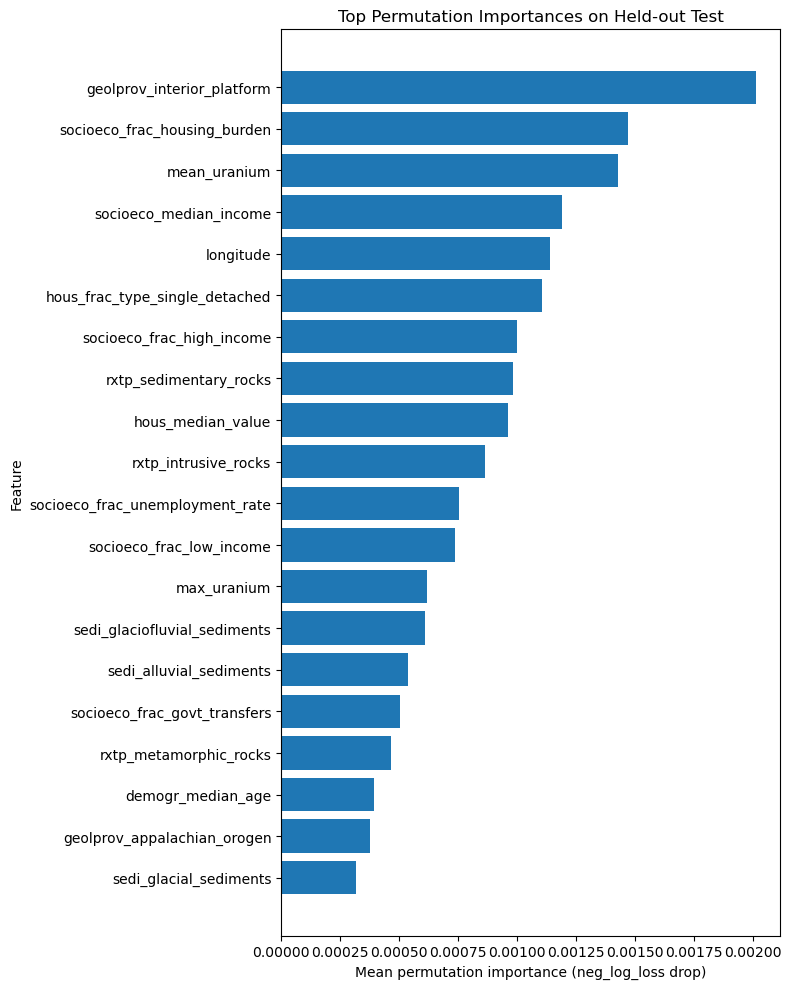

In [12]:
top_k = 20
plot_df = permutation_importance_df.head(top_k).iloc[::-1]

plt.figure(figsize=(8, 10))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Mean permutation importance (neg_log_loss drop)")
plt.ylabel("Feature")
plt.title("Top Permutation Importances on Held-out Test")
plt.tight_layout()
plt.savefig(RUN_DIR / "permutation_importance_top20.png", dpi=300, bbox_inches="tight")
plt.show()

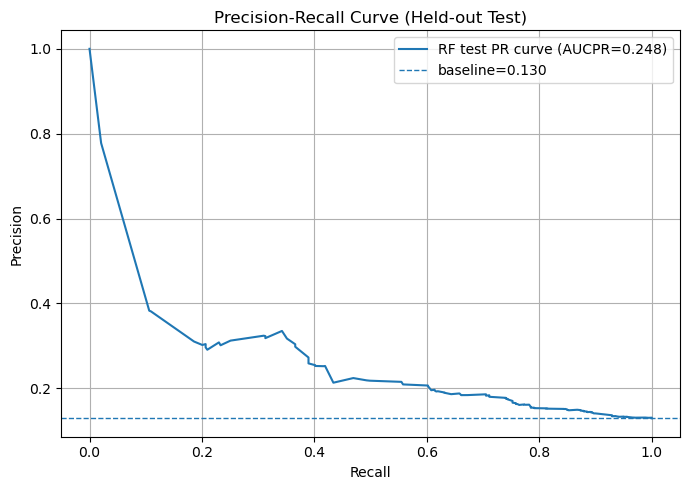

In [13]:
precision, recall, _ = precision_recall_curve(y_test, test_prob)
baseline_prevalence = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"RF test PR curve (AUCPR={test_metrics['test_aucpr']:.3f})")
plt.axhline(y=baseline_prevalence, linestyle="--", linewidth=1, label=f"baseline={baseline_prevalence:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Held-out Test)")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig(RUN_DIR / "pr_curve_test.png", dpi=300, bbox_inches="tight")
plt.show()

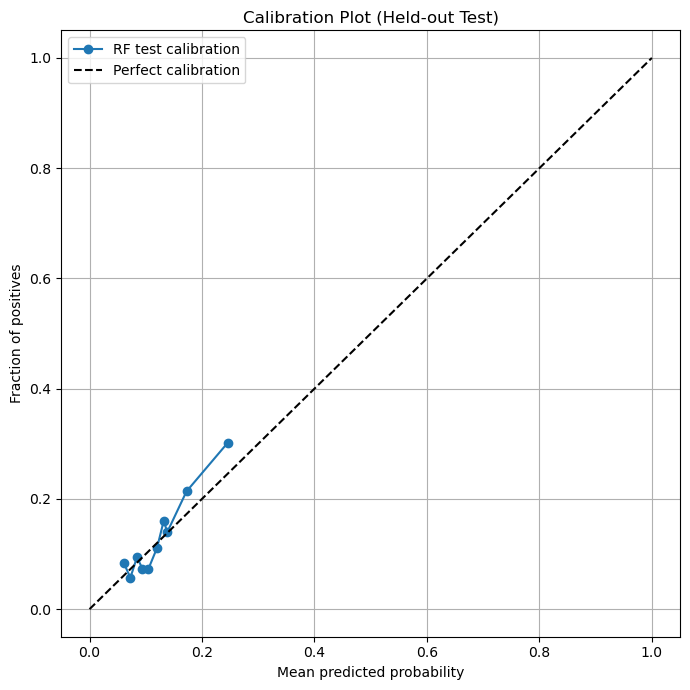

In [14]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test,
    test_prob,
    n_bins=N_CALIBRATION_BINS,
    strategy="quantile",
)

plt.figure(figsize=(7, 7))
plt.plot(mean_predicted_value, fraction_of_positives, marker="o", label="RF test calibration")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot (Held-out Test)")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig(RUN_DIR / "calibration_plot_test.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
thresholds_to_check = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
threshold_rows = []

for threshold in thresholds_to_check:
    test_pred = (test_prob >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, test_pred),
        "recall": recall_score(y_test, test_pred, zero_division=0),
        "f1": f1_score(y_test, test_pred, zero_division=0),
        "predicted_positive_rate": test_pred.mean(),
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(RUN_DIR / "threshold_sweep.csv", index=False)
threshold_df

,threshold,accuracy,recall,f1,predicted_positive_rate
0,0.05,0.136850,1.000000,0.230926,0.992737
1,0.10,0.478976,0.752212,0.272290,0.586391
2,0.15,0.782110,0.389381,0.316547,0.189220
3,0.20,0.831422,0.250737,0.278232,0.103976
4,0.25,0.861621,0.109145,0.169725,0.037080
5,0.30,0.870413,0.000000,0.000000,0.000000


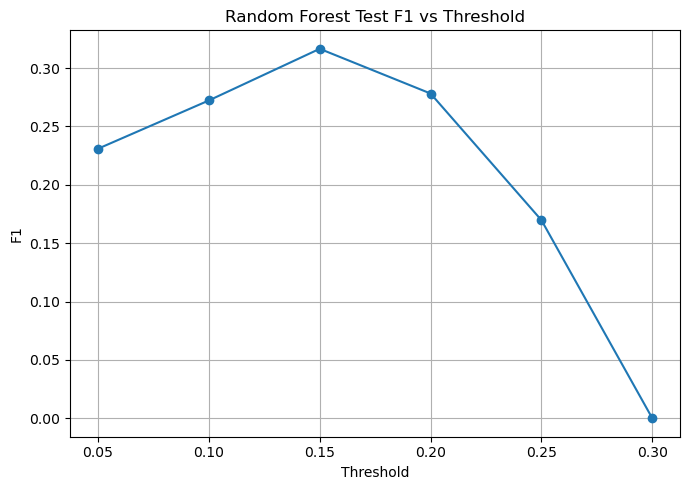

In [16]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("Random Forest Test F1 vs Threshold")
plt.grid(True)
plt.tight_layout()
plt.savefig(RUN_DIR / "f1_vs_threshold_test.png", dpi=300, bbox_inches="tight")
plt.show()